# FEATURE-BASED SET OF EXPERIMENTS: MULTILABEL CLASSIFIER
**Hypothesis:** This set of experiments are based on the hypothesis that training "simpler" Machine Learning algorithms with lesser but more relevant data, the performance in classifying the site of origin will increase. Given that this is what was seen for binary label classification, it's hypothesized that the utility of the selected features for task one, will be consistent to this set of experiments.

**Content of the file:** This file contains a first experiment to assess the performance of classical ML learning algorithms (LogReg, XGBoost, Random Forest, Support Vector Machines) trained on all the available datasets coombined. For this first approach, no clinical data is included because since it's only available on teknon, it would mean imputing or padding all the other cases.
Secondly, an experiment with the same algorithms for just Teknon including the clinical data is performed. This pair of experiments will help to assess whether is more important to have more data or more refined data in our context of use (evaludating on Teknon).

### Imports & Paths

In [27]:
import os
import pickle
import numpy as np
import pandas as pd
import shap
from scipy.stats import skew, kurtosis
from scipy import signal
from scipy.io import loadmat
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier


In [8]:
#If executing from collab
'''from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/Shareddrives/CompBioMed/seminars"
'''

'from google.colab import drive\ndrive.mount(\'/content/drive\')\n\nbase_path = "/content/drive/Shareddrives/CompBioMed/seminars"\n'

In [9]:
base_path =''
PATH_ALIGNED = os.path.join(base_path, 'outputs', 'aligned_qrs.pkl')
PATH_IDENTIFIERS = os.path.join(base_path, 'outputs', 'qrs_identifiers.pkl')
PATH_TABULAR_PARQUET = os.path.join(base_path, 'data', 'multiclass_full_dataset.parquet')

PATH_CLINIC = os.path.join(base_path, 'data',    'QRS_CARTO2.mat')
PATH_CHINA = os.path.join(base_path, 'data',    'QRS_Database2.mat')
PATH_SIMS = os.path.join(base_path, 'data',    'QRS_Sims2.mat')

LEAD_COLS = ['I','II','III','AVR','AVL','AVF','V1','V2','V3','V4','V5','V6']
LEADS = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
PRECORDIALS = ["V1", "V2", "V3", "V4", "V5", "V6"]
TRANSITION_MAPPING = {"V1": 1, "V2": 2, "V3": 3, "V4": 4, "V5": 5, "V6": 6}

TARGET_COL = 'Final_Label'
CLASS_NAMES = ['LCC', 'RCC', 'COMMISSURE', 'LVOT Subvalvular', 'LVOT Summit', 'RVOT Septum', 'RVOT Free Wall']
CLASS_MAPPING = {
    'LCC': 0, 'RCC': 1, 'COMMISSURE': 2, 'LVOTSUBVALVULAR': 3,
    'LVOTSUMMIT': 4, 'RVOTSEPTUM': 5, 'SEPTUM': 5, 'RVOTFREEWALL': 6, 'RFW': 6}


### Utils 

In [10]:
def compute_transition(pacient_feats, precordials = PRECORDIALS):
    '''Compute the PVC transition for the datasets that don't have it 
    available as clinical data. By looking at which precordial lead 
    the R wave is greater than the S wave.'''

    ratios = []

    for lead in precordials:
        r_amp = pacient_feats[f'{lead}_R_amp'] 
        s_amp = pacient_feats[f'{lead}_S_amp'] 

        R = r_amp
        S = abs(s_amp)

        ratio = np.inf if S == 0 else R / S
        ratios.append(ratio)

    ratios = np.array(ratios)

    # Keep the first lead where R>=S
    idx = np.where(ratios >= 1)[0]

    string_trans = precordials[idx[0]] if len(idx) > 0 else "V6"
    return TRANSITION_MAPPING[string_trans]

def extract_ecg_features(X_signals, calculate_transition=False):
    '''Extract the significant selected features from the ECG. Only trigger 
    compute_transition for datasets that don't have the tabular data, otherwise
    keep the clinical values since most are written by a professional'''

    features_list = []

    for i_pacient in range(len(X_signals)):
        pacient_feats = {}

        # Calculate the 6 features for every lead (72 features)
        for i_lead, lead_name in enumerate(LEADS):
            senyal = X_signals[i_pacient, i_lead, :]
            r_amp = np.max(senyal)
            s_amp = np.min(senyal)
            rs_ratio = r_amp / (abs(s_amp) + 1e-6)
            rms = np.sqrt(np.mean(senyal**2))
            kurt = kurtosis(senyal)
            asimetria = skew(senyal)

            pacient_feats[f'{lead_name}_R_amp'] = r_amp
            pacient_feats[f'{lead_name}_S_amp'] = s_amp
            pacient_feats[f'{lead_name}_RS_ratio'] = rs_ratio
            pacient_feats[f'{lead_name}_RMS'] = rms
            pacient_feats[f'{lead_name}_Kurtosis'] = kurt
            pacient_feats[f'{lead_name}_Skewness'] = asimetria

        if calculate_transition:
            pacient_feats['PVC_transition'] = compute_transition(pacient_feats)
        features_list.append(pacient_feats)
        
    return pd.DataFrame(features_list)

In [11]:
def _handle_sublocation_mat(dSim: dict, data_key: str, path: str, X: np.ndarray):
    mapping = {
        'LCC': 0, 'RCC': 1, 'COMMISSURE': 2, 'LVOT Subvalvular': 3,
        'LVOT Summit': 4, 'RVOT Septum': 5, 'RFW': 6
    }
    invalid_labels = ['RV', []] if path == PATH_CLINIC else (['-', 'RVOTOther'] if path == PATH_CHINA else [])
    raw_labels = dSim[data_key]["Sublocation"]

    y_sub, valid_indices = [], []
    for i, label in enumerate(raw_labels[0]):
        try:
            if label[0] in invalid_labels: continue
            lbl = label[0]
            if lbl in ['LCCRCC', 'LCC-RCC']: lbl = 'COMMISSURE'
            elif lbl in ['Posteroseptal', 'Anteroseptal']: lbl = 'RVOT Septum'
            elif lbl == "AMC": lbl = 'LVOT Subvalvular'
            elif lbl == "Summit": lbl = 'LVOT Summit'

            if lbl in mapping:
                y_sub.append(mapping[lbl])
                valid_indices.append(i)
        except:
            continue
    return X[valid_indices], np.array(y_sub, dtype=np.int64)

def load_and_extract_mat_dataset(path: str, sample_size: int, data_key: str):
    print(f"Loading external dataset from: {path}")
    dSim = loadmat(path)
    mat_leads = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
    n_patients = dSim[data_key][mat_leads[0]].shape[1]

    X_raw = np.zeros((n_patients, len(mat_leads), sample_size))
    for iLead, lead in enumerate(mat_leads):
        lead_data = dSim[data_key][lead]
        for i in range(n_patients):
            patient_signal = lead_data[0, i]
            signal_1d = np.asarray(patient_signal).squeeze()
            if signal_1d.ndim != 1: continue
            resampled = signal.resample(signal_1d, sample_size)
            if np.max(np.abs(resampled)) > 0:
                resampled = resampled / np.max(np.abs(resampled))
            X_raw[i, iLead, :] = resampled

    X_signals, y_labels = _handle_sublocation_mat(dSim, data_key, path, X_raw)
    df_mat_feats = extract_ecg_features(X_signals, calculate_transition=True)
    df_mat_feats[TARGET_COL] = y_labels
    return df_mat_feats

### 1. All Datasets
This first experiment compares the performance of 4 machine learning algorithms in the combined dataset. A cross-validation of 5 folds is done with evaluation only on Teknon. This is followed by a shap analysis where the priority or use of the features is displayed

In [ ]:
print("--- LOADING TEKNON ---")

# Open the files with the QRS data and the identifiers
with open(PATH_ALIGNED, 'rb') as f:
    aligned_ecgs = pickle.load(f)
with open(PATH_IDENTIFIERS, 'rb') as f:
    df_id = pickle.load(f)

# Reshape to the standard
X_teknon_all = np.array(aligned_ecgs, dtype=np.float32)
if X_teknon_all.shape[1] == 277:
    X_teknon_all = np.transpose(X_teknon_all, (0, 2, 1))

# Load the clinical data file to load the labels
df_parquet = pd.read_parquet(PATH_TABULAR_PARQUET)
if 'patient_id' in df_parquet.columns:
    df_parquet = df_parquet.set_index('patient_id')

# Map the classess and drop the taget column
df_parquet[TARGET_COL] = df_parquet[TARGET_COL].astype(str).str.strip().str.upper().map(CLASS_MAPPING)
df_parquet = df_parquet.dropna(subset=[TARGET_COL])

# Align the files (QRS + clinical data) to match labels
indices_comuns = df_id.index.intersection(df_parquet.index)
posicions_ecg = [df_id.index.get_loc(idx) for idx in indices_comuns]
X_tek_filtered = X_teknon_all[posicions_ecg]

# Extract the features for Teknon
df_features_tek = extract_ecg_features(X_tek_filtered, calculate_transition=False)
df_features_tek.index = indices_comuns
df_features_tek[TARGET_COL] = df_parquet.loc[indices_comuns, TARGET_COL].values

# Include the validated PVC transition if existent
parquet_trans_col = 'PVC_transition' if 'PVC_transition' in df_parquet.columns else 'transition'
if parquet_trans_col in df_parquet.columns:
    df_features_tek['PVC_transition'] = df_parquet.loc[indices_comuns, parquet_trans_col].values
else: # It shouldn't go here but just in case
    df_features_tek['PVC_transition'] = extract_ecg_features(X_tek_filtered, calculate_transition=True)['PVC_transition'].values

# Separate the Hold-out (80% Train, 20% Test)
split_idx = int(0.8 * len(df_features_tek))
df_tek_train_full = df_features_tek.iloc[:split_idx].copy()
df_tek_test_full = df_features_tek.iloc[split_idx:].copy()

# Load the other available datasets (the features are already extracted inside the function)
df_china_processed = load_and_extract_mat_dataset(PATH_CHINA, sample_size=277, data_key='QRS')
df_clinic_processed = load_and_extract_mat_dataset(PATH_CLINIC, sample_size=277, data_key='QRS_CARTO')
df_sims_processed = load_and_extract_mat_dataset(PATH_SIMS, sample_size=277, data_key='QRS_Sims')

# Concatenate all the datasets
df_extra_all = pd.concat([df_china_processed, df_clinic_processed, df_sims_processed], axis=0, ignore_index=True)

# Separate into X = features and y = labels without leaking data
y_tek_train_all = df_tek_train_full[TARGET_COL].values.astype(np.int64)
X_tek_train_all = df_tek_train_full.drop(columns=[TARGET_COL]).values
X_extra_values = df_extra_all.drop(columns=[TARGET_COL]).values
y_extra_values = df_extra_all[TARGET_COL].values.astype(np.int64)


In [13]:
# 5-Fold Cross Validation with predetermined parameters
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models_tots = {
    'XGBoost': xgb.XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, objective='multi:softprob', num_class=7, random_state=42, eval_metric='mlogloss'),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=6, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', C=1.0, probability=True, decision_function_shape='ovr', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1500, multi_class='ovr', random_state=42)
}

diccionari_scores = {nom_model: [] for nom_model in models_tots.keys()}

# 5-Fold loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X_tek_train_all, y_tek_train_all), 1):
    X_val_fold = X_tek_train_all[val_idx]
    y_val_fold = y_tek_train_all[val_idx]
    X_train_fold = np.concatenate([X_tek_train_all[train_idx], X_extra_values], axis=0)
    y_train_fold = np.concatenate([y_tek_train_all[train_idx], y_extra_values], axis=0)

    # Imputing and scaling are mandatory for some of the models (RF, XGBoost)
    imputer = SimpleImputer(strategy='median')
    X_train_imputed = imputer.fit_transform(X_train_fold)
    X_val_imputed = imputer.transform(X_val_fold)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    X_val_scaled = scaler.transform(X_val_imputed)

    for nom_model, model in models_tots.items():
        if nom_model in ['Support Vector Machine', 'Logistic Regression']:
            model.fit(X_train_scaled, y_train_fold)
            preds = model.predict(X_val_scaled)
        else:
            model.fit(X_train_imputed, y_train_fold)
            preds = model.predict(X_val_imputed)
        diccionari_scores[nom_model].append(f1_score(y_val_fold, preds, average='macro', zero_division=0))

print("\n--- CV Results (Evaluated ONLY on Teknon) ---")
for nom_model in models_tots.keys():
    print(f"{nom_model}: {np.mean(diccionari_scores[nom_model]):.4f}")




--- CV Results (Evaluated ONLY on Teknon) ---
XGBoost: 0.1435
Random Forest: 0.1256
Support Vector Machine: 0.0938
Logistic Regression: 0.1509



Model: XGBoost | Test Macro F1: 0.1113


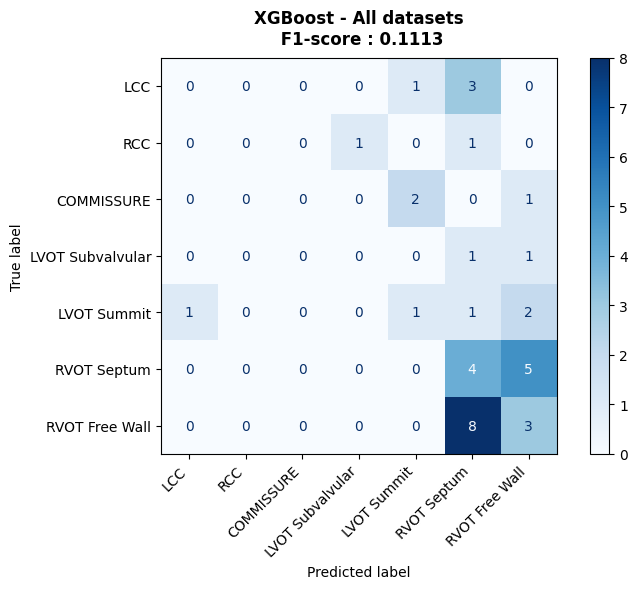


Model: Random Forest | Test Macro F1: 0.0823


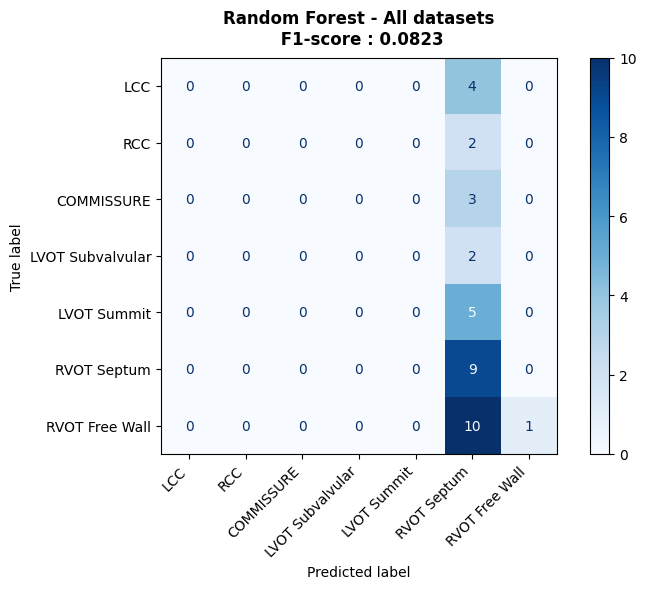


Model: Support Vector Machine | Test Macro F1: 0.0823


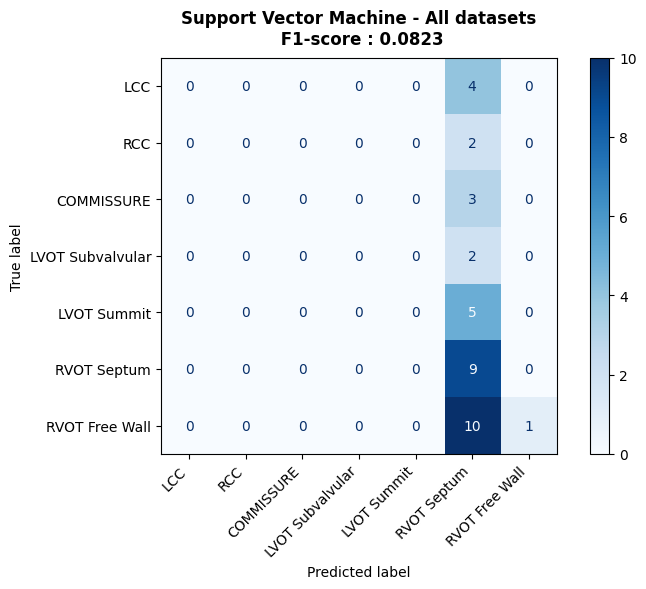


Model: Logistic Regression | Test Macro F1: 0.1813


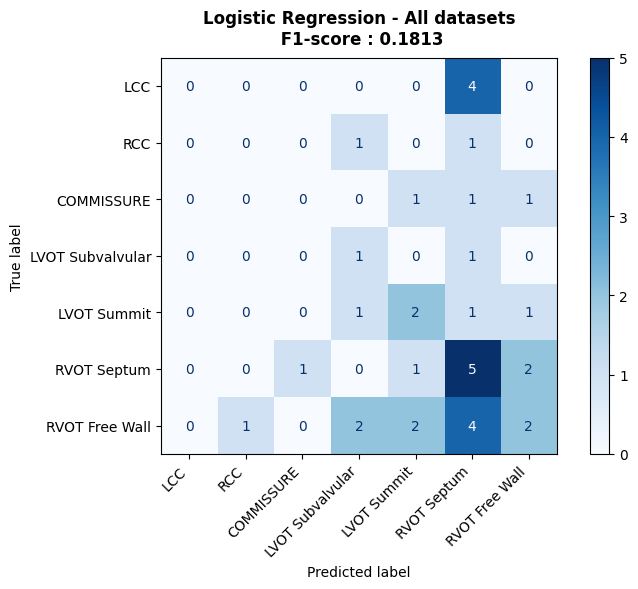

In [15]:
# Evaluation on Holdout
X_train_final_all = np.concatenate([X_tek_train_all, X_extra_values], axis=0)
y_train_final_all = np.concatenate([y_tek_train_all, y_extra_values], axis=0)
X_test_final = df_tek_test_full.drop(columns=[TARGET_COL]).values
y_test_final = df_tek_test_full[TARGET_COL].values.astype(np.int64)

full_imputer = SimpleImputer(strategy='median')
X_train_full_imp = full_imputer.fit_transform(X_train_final_all)
X_test_final_imp = full_imputer.transform(X_test_final)

full_scaler = StandardScaler()
X_train_full_scaled = full_scaler.fit_transform(X_train_full_imp)
X_test_final_scaled = full_scaler.transform(X_test_final_imp)

for nom_model, model in models_tots.items():
    if nom_model in ['Support Vector Machine', 'Logistic Regression']:
        model.fit(X_train_full_scaled, y_train_final_all)
        test_preds = model.predict(X_test_final_scaled)
    else:
        model.fit(X_train_full_imp, y_train_final_all)
        test_preds = model.predict(X_test_final_imp)

    # Compute the f1 score (since it's the chosen parameter)
    f1_test = f1_score(y_test_final, test_preds, average='macro', zero_division=0)
    print(f"\nModel: {nom_model} | Test Macro F1: {f1_test:.4f}")

    # Create and display the confusion matrix
    cm = confusion_matrix(y_test_final, test_preds)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
    ax.set_title(f"{nom_model} - All datasets\n F1-score : {f1_test:.4f}", fontsize=12, weight='bold', pad=10)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


--- Running SHAP for Multimodal Logistic Regression ---


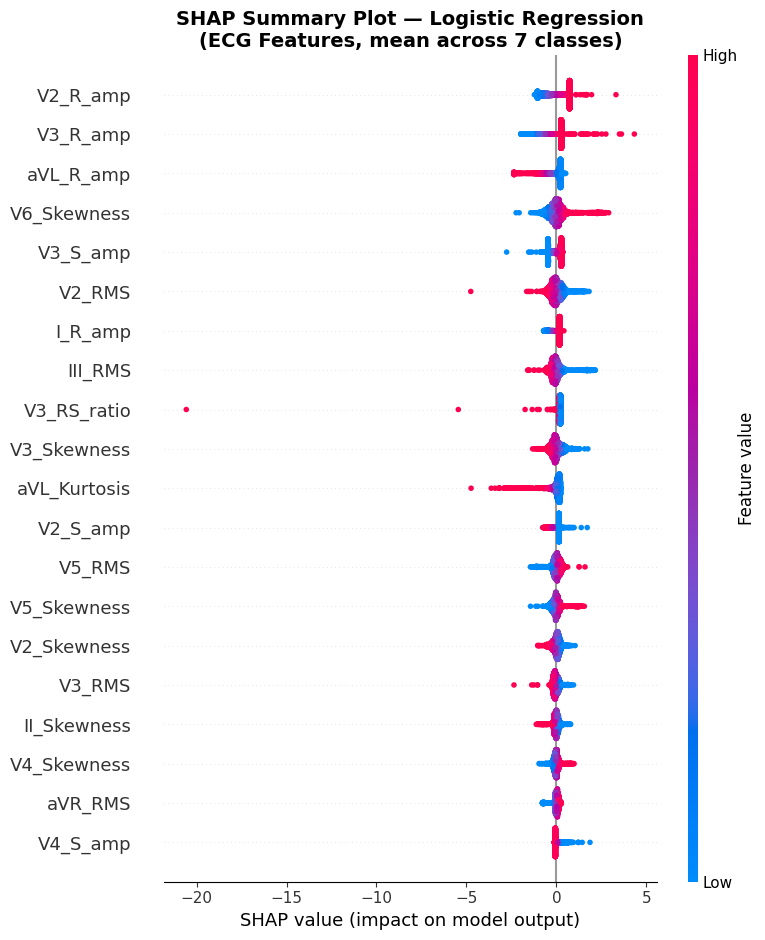

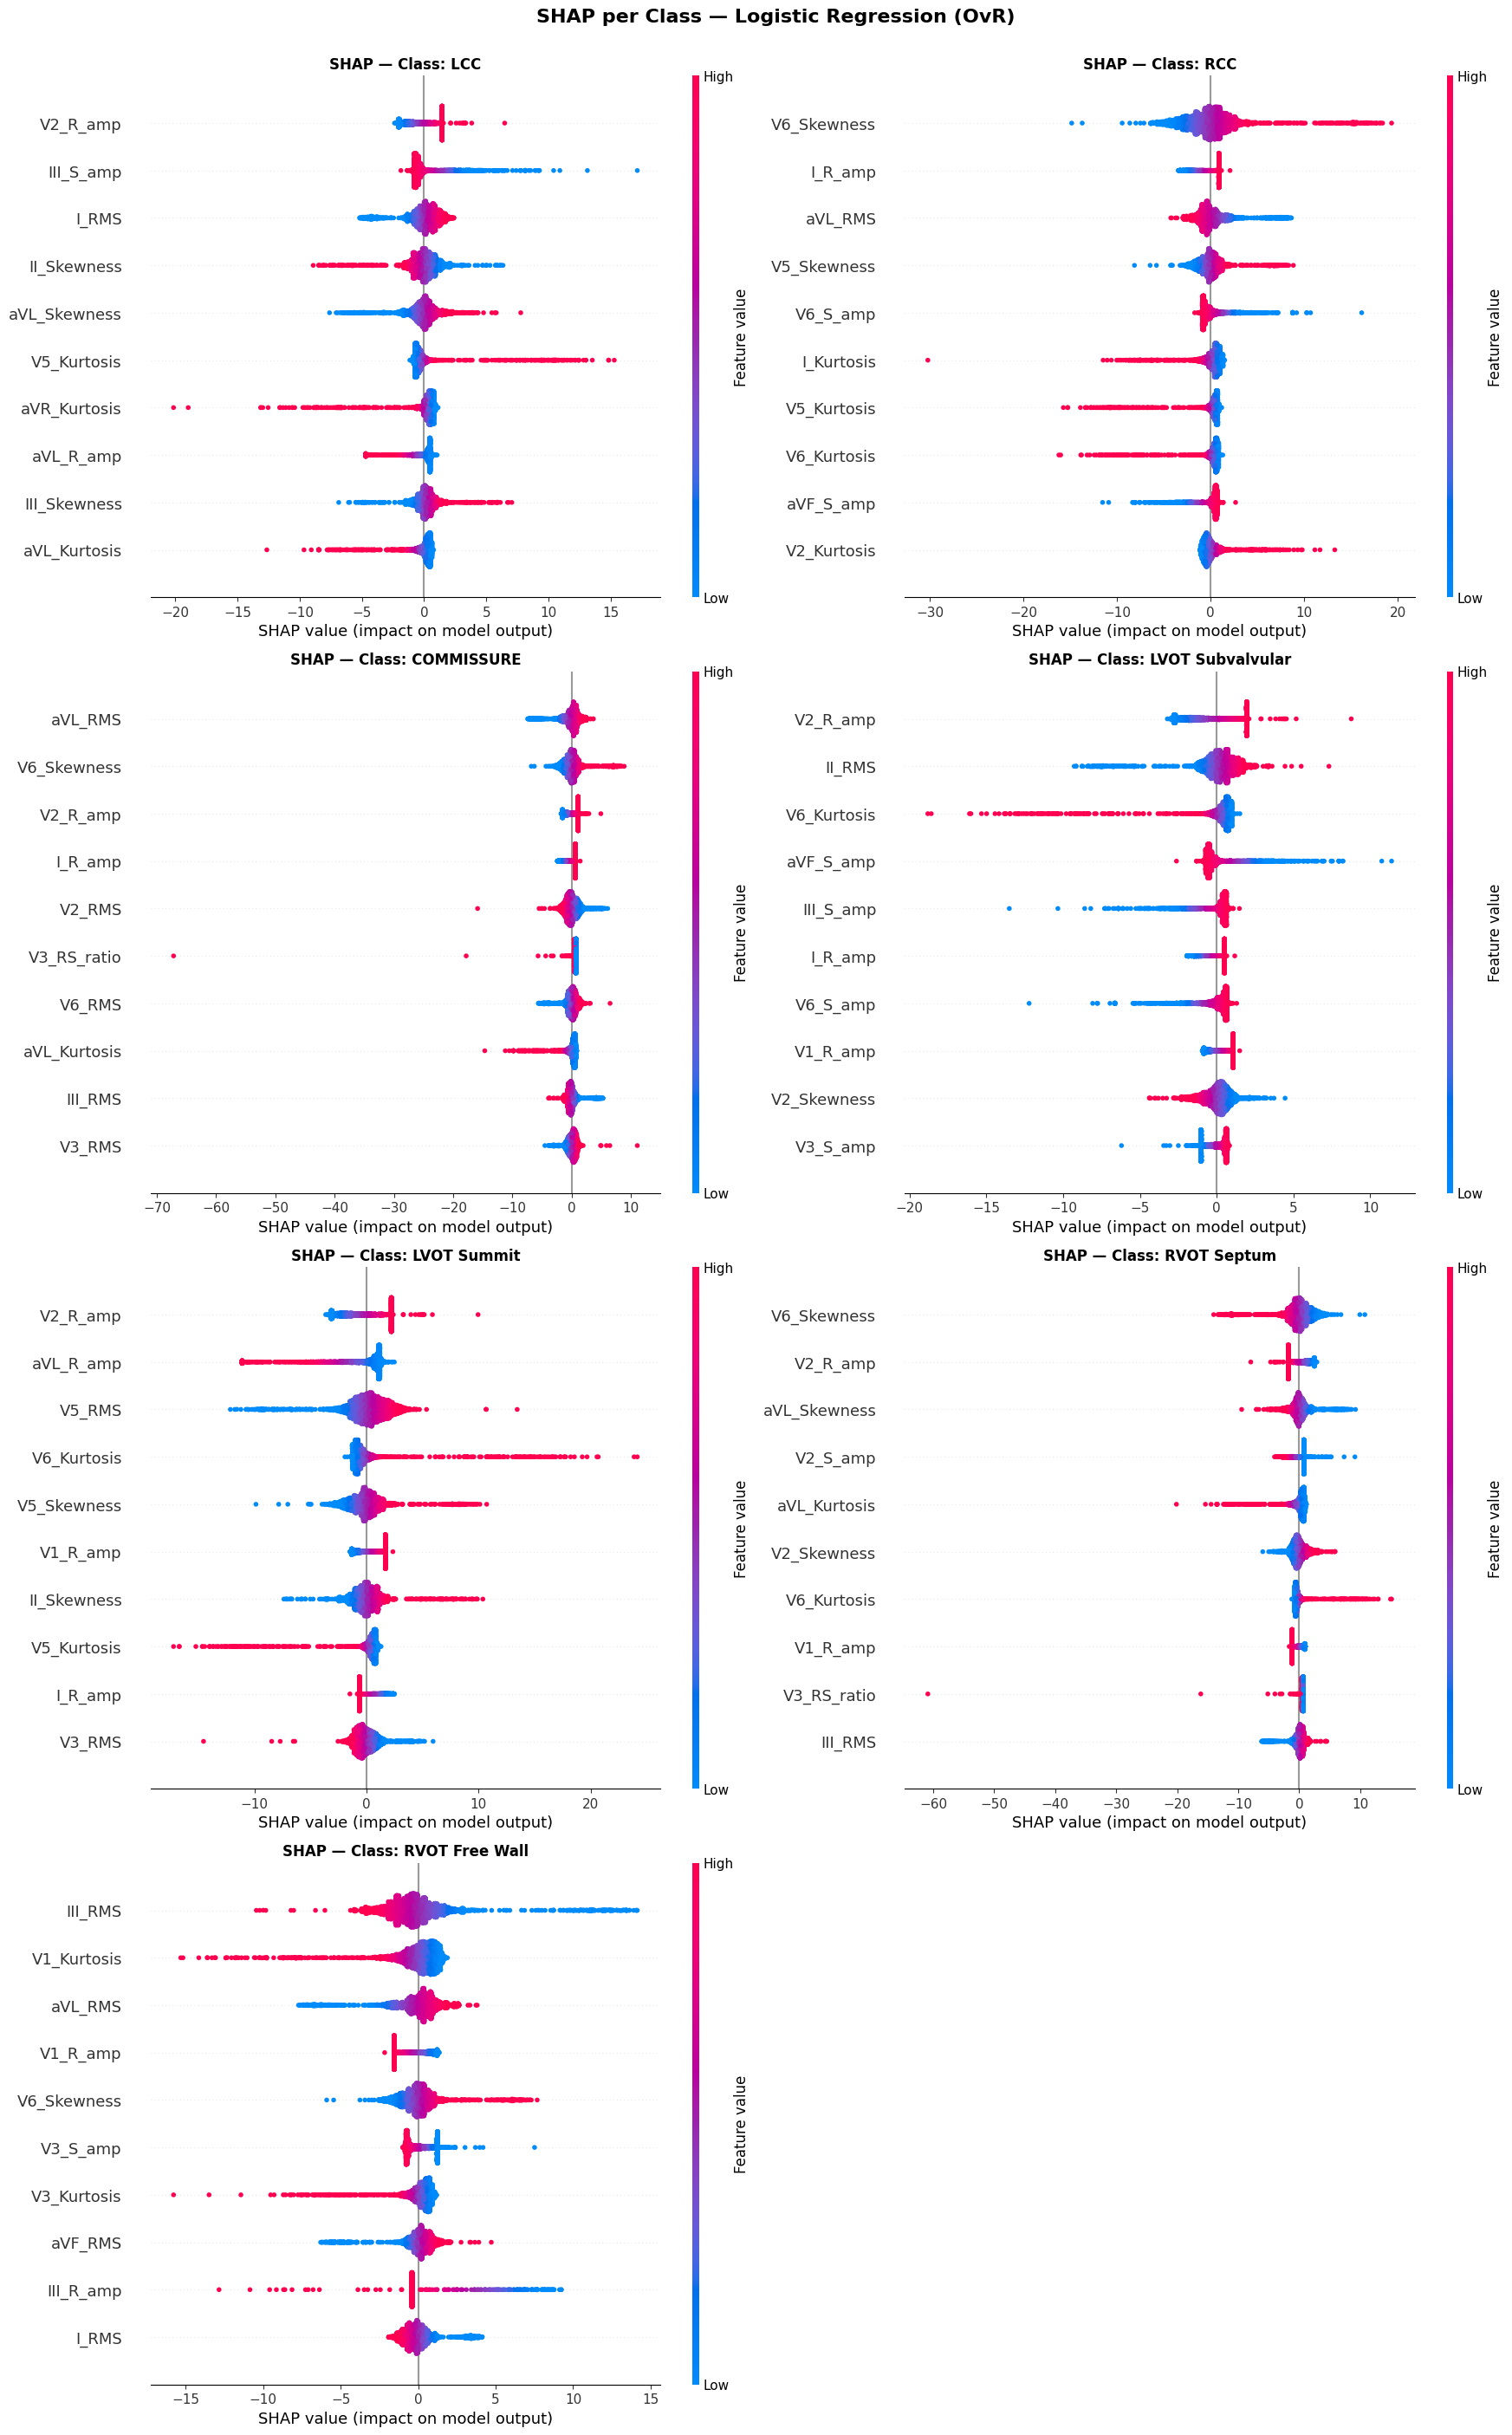

In [ ]:
# SHAP analysis for logistic regression

print("\n--- Running SHAP for Multimodal Logistic Regression ---")

# Retrain the model 
shap_model_lr = OneVsRestClassifier(LogisticRegression(max_iter=1500, random_state=42))
shap_model_lr.fit(X_train_full_scaled, y_train_final_all)

# Extract coeficients and interceptors
coefs = np.array([est.coef_[0] for est in shap_model_lr.estimators_])
intercepts = np.array([est.intercept_[0] for est in shap_model_lr.estimators_])

# Execute liniar explainer
explainer_lr = shap.LinearExplainer((coefs, intercepts), X_train_full_scaled)
shap_values_lr = explainer_lr.shap_values(X_train_full_scaled)

# Ensure format for the subplots [n_classes](n_samples, n_features)
if isinstance(shap_values_lr, list):
    shap_values_per_class = shap_values_lr
    shap_array = np.array(shap_values_lr)  # (7, n_samples, n_features)
else:
    shap_array = np.array(shap_values_lr)
    if shap_array.ndim == 3:
        if shap_array.shape[2] == 7:     # Si és (n_samples, n_features, n_classes)
            shap_array = np.transpose(shap_array, (2, 0, 1))
        elif shap_array.shape[1] == 7:   # Si és (n_samples, n_classes, n_features)
            shap_array = np.transpose(shap_array, (1, 0, 2))
    shap_values_per_class = [shap_array[i] for i in range(len(CLASS_NAMES))]

# Recuperate the features names
feature_names_tots = list(df_tek_train_full.drop(columns=[TARGET_COL]).columns)

# Global beeswarm plot
shap_mean_per_sample = shap_array.mean(axis=0) 

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_mean_per_sample,
    X_train_full_scaled,
    feature_names=feature_names_tots,
    max_display=20,
    show=False
)
plt.title("SHAP Summary Plot — Logistic Regression\n(ECG Features, mean across 7 classes)",
          fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# Per-class beeswarm plot
fig, axes = plt.subplots(4, 2, figsize=(18, 28))
axes = axes.flatten()

for i, cname in enumerate(CLASS_NAMES):
    plt.sca(axes[i])
    
    shap.summary_plot(
        shap_values_per_class[i],
        X_train_full_scaled,
        feature_names=feature_names_tots,
        max_display=10,
        show=False,
        plot_size=None
    )
    axes[i].set_title(f"SHAP — Class: {cname}", fontsize=12, weight='bold')

axes[-1].set_visible(False)

plt.suptitle("SHAP per Class — Logistic Regression (OvR)", fontsize=16, weight='bold', y=1.002)
plt.tight_layout()
plt.show()

### Machine learning on Teknon + clinical data
This second experiment aims to assess if adding the clinical variables available for teknon adds predictive capability in comparison with the models trained with more diverse data. 5-fold cross validation assessed on teknon is done for all the 4 selected models (LogReg, SVM, XGBoost, Random Forest), tested on the hold-out set. Extracted features are the same as before (6 features x 12 leads + pvc transition).

In [20]:
# Reloading the data to include clinical variables
print("--- RELOADING DATA FOR CLINICAL + ECG INTEGRATION ---")
df_clinics_tek = pd.read_parquet(PATH_TABULAR_PARQUET)
df_clinics_tek = df_clinics_tek.drop(columns=['I','II','III','AVR','AVL','AVF','V1','V2','V3','V4','V5','V6'], errors='ignore')

if 'patient_id' in df_clinics_tek.columns:
    df_clinics_tek = df_clinics_tek.set_index('patient_id')

df_clinics_tek[TARGET_COL] = df_clinics_tek[TARGET_COL].astype(str).str.strip().str.upper().map(CLASS_MAPPING)
df_clinics_tek = df_clinics_tek.dropna(subset=[TARGET_COL])

indices_comuns_tek = df_id.index.intersection(df_clinics_tek.index)
X_tek_raw = X_teknon_all[[df_id.index.get_loc(idx) for idx in indices_comuns_tek]]
df_clinics_tek = df_clinics_tek.loc[indices_comuns_tek].copy()

# Extracting features
features_tek_list = []
for i in range(len(X_tek_raw)):
    feats = {}
    for j, lead in enumerate(["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]):
        sig = X_tek_raw[i, j, :]
        r, s = np.max(sig), np.min(sig)
        feats[f"{lead}_R"] = r
        feats[f"{lead}_S"] = s
        feats[f"{lead}_RS"] = r / (abs(s) + 1e-6)
        feats[f"{lead}_RMS"] = np.sqrt(np.mean(sig**2))
        feats[f"{lead}_kurt"] = kurtosis(sig)
        feats[f"{lead}_skew"] = skew(sig)
    features_tek_list.append(feats)

X_feat_tek = pd.DataFrame(features_tek_list, index=indices_comuns_tek)
df_merged_tek = pd.concat([df_clinics_tek, X_feat_tek], axis=1)

# Drop the possible data-leaking columns (none should be there but just in case)
drop_cols = ['Chamber_Type', 'site_of_origin', 'Site_Of_Origin', 'SOO', 'sublocation']
df_merged_tek = df_merged_tek.drop(columns=[c for c in drop_cols if c in df_merged_tek.columns])

# Drop the target and One-hot-encode the categorical columns
X_df_tek = df_merged_tek.drop(columns=[TARGET_COL])
cat_cols = X_df_tek.select_dtypes(include=['object', 'category']).columns
X_df_tek = pd.get_dummies(X_df_tek, columns=cat_cols, drop_first=True)

X_all_tek = X_df_tek.values
y_all_tek = df_merged_tek[TARGET_COL].values.astype(int)

# DEfine the splitting point and apply it
split_idx = int(0.8 * len(X_all_tek))

X_train_t = X_all_tek[:split_idx]
y_train_t = y_all_tek[:split_idx]

X_test_t = X_all_tek[split_idx:]
y_test_t = y_all_tek[split_idx:]

# Some algorithms require Imputation of possible nan values
imputer_t = SimpleImputer(strategy="median")
X_train_t = imputer_t.fit_transform(X_train_t)
X_test_t = imputer_t.transform(X_test_t)

--- RELOADING DATA FOR CLINICAL + ECG INTEGRATION ---



--- TEKNON CLINICAL+ECG MODEL COMPARISON ---
LogReg Test Macro F1: 0.2234


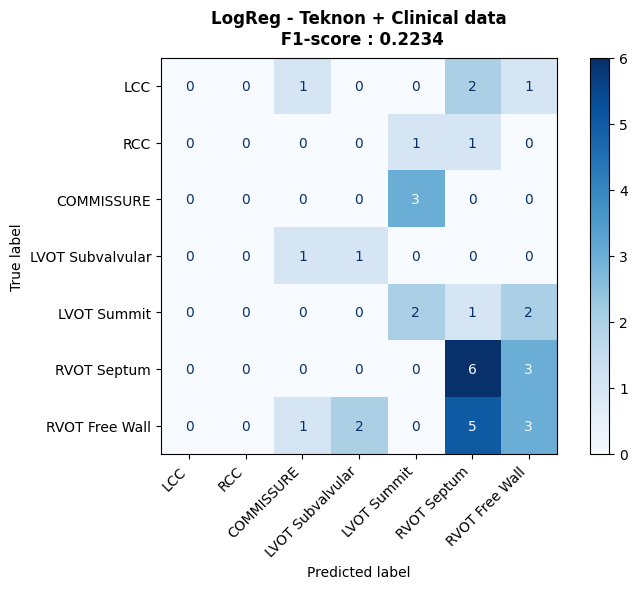

SVM Test Macro F1: 0.0286


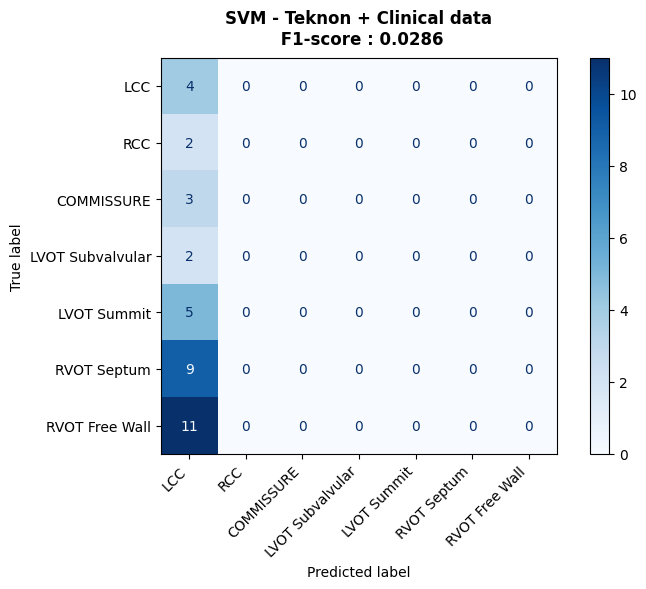

RandomForest Test Macro F1: 0.1519


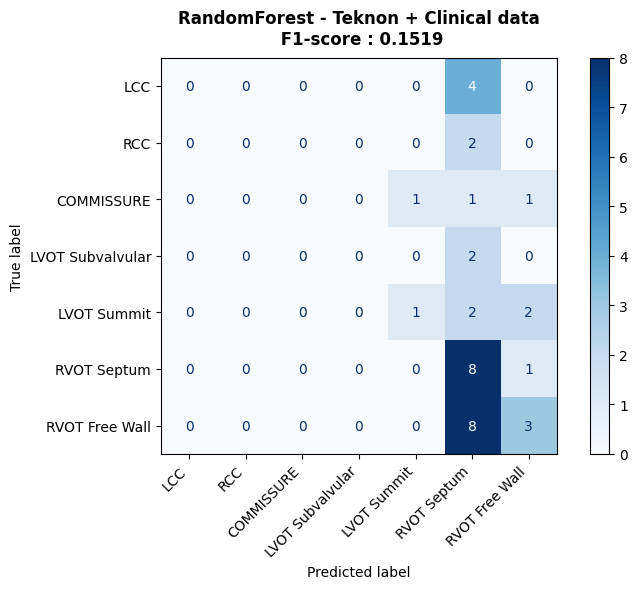

XGBoost Test Macro F1: 0.0894


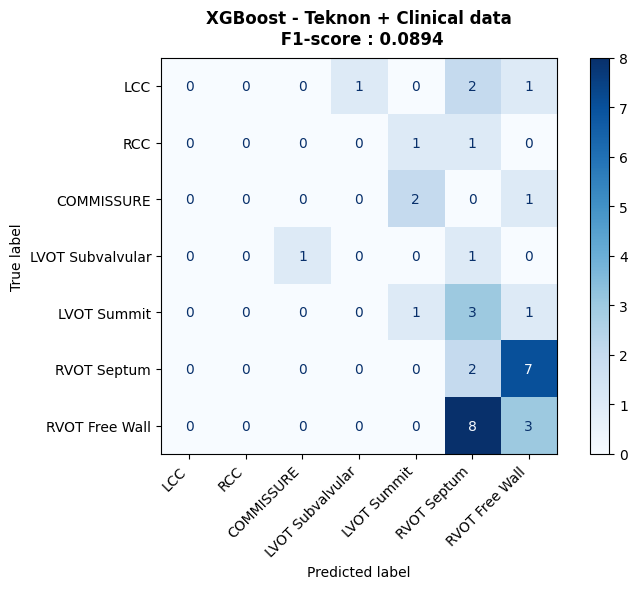

In [24]:
# Machine Learning Algorithms
models_tek = {
    "LogReg": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "SVM": SVC(kernel="rbf", class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample", random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(objective="multi:softprob", num_class=len(np.unique(y_all_tek)), eval_metric="mlogloss", random_state=42)
}

# Train and display the performance on test
print("\n--- TEKNON CLINICAL+ECG MODEL COMPARISON ---")
for name, model in models_tek.items():
    model.fit(X_train_t, y_train_t)
    preds = model.predict(X_test_t)
    f1_value=f1_score(y_test_t, preds, average='macro', zero_division=0)
    print(f"{name} Test Macro F1: {f1_value:.4f}")

    # Generate and display confusion matrix
    cm = confusion_matrix(y_test_t, preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
    ax.set_title(f"{name} - Teknon + Clinical data\n F1-score : {f1_value:.4f}", fontsize=12, weight='bold', pad=10)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

An hyperparameter search is done on Logistic Regression (the best performing multilabel classifier so far) and in extreme gradient boosting, since they are the best performing model in multilabel classification and the model responding better to this type of random search hyperarameter optimization.


--- OPTIMIZING LOGISTIC REGRESSION VIA RANDOM SEARCH ---


The max_iter was reached which means the coef_ did not converge


Best LR Params: {'solver': 'saga', 'penalty': 'l1', 'class_weight': None, 'C': 0.012742749857031334}


The max_iter was reached which means the coef_ did not converge


Optimized Logistic Regression Test Macro F1: 0.0571


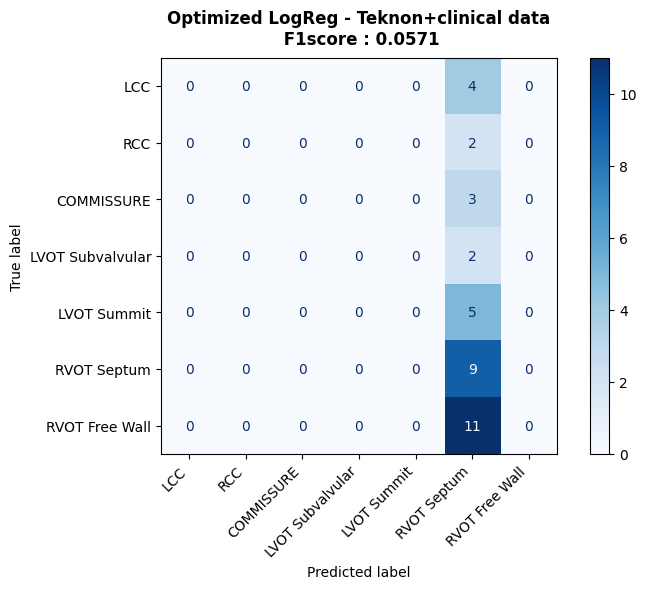


--- OPTIMIZING XGBOOST VIA RANDOM SEARCH ---
Best XGB Params: {'subsample': 0.8, 'reg_lambda': 5, 'n_estimators': 400, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.05999999999999999, 'gamma': 0.4, 'colsample_bytree': 0.6}
Optimized XGBoost Test Macro F1: 0.1587


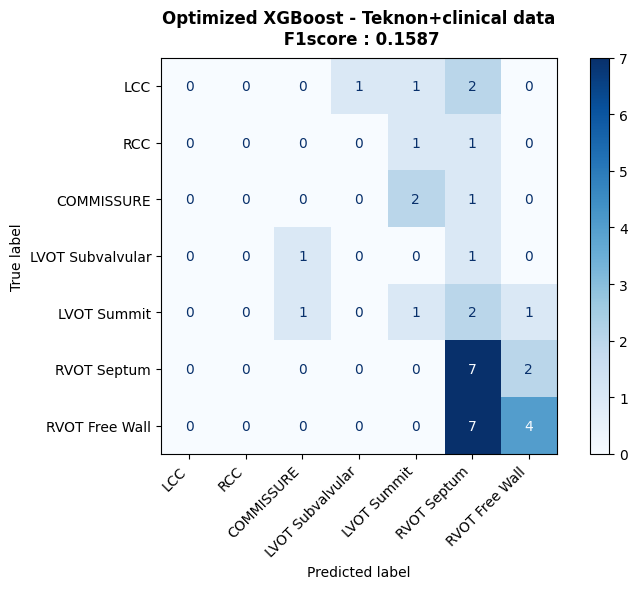


--- RUNNING SHAP ANALYSIS FOR OPTIMIZED XGBOOST ---


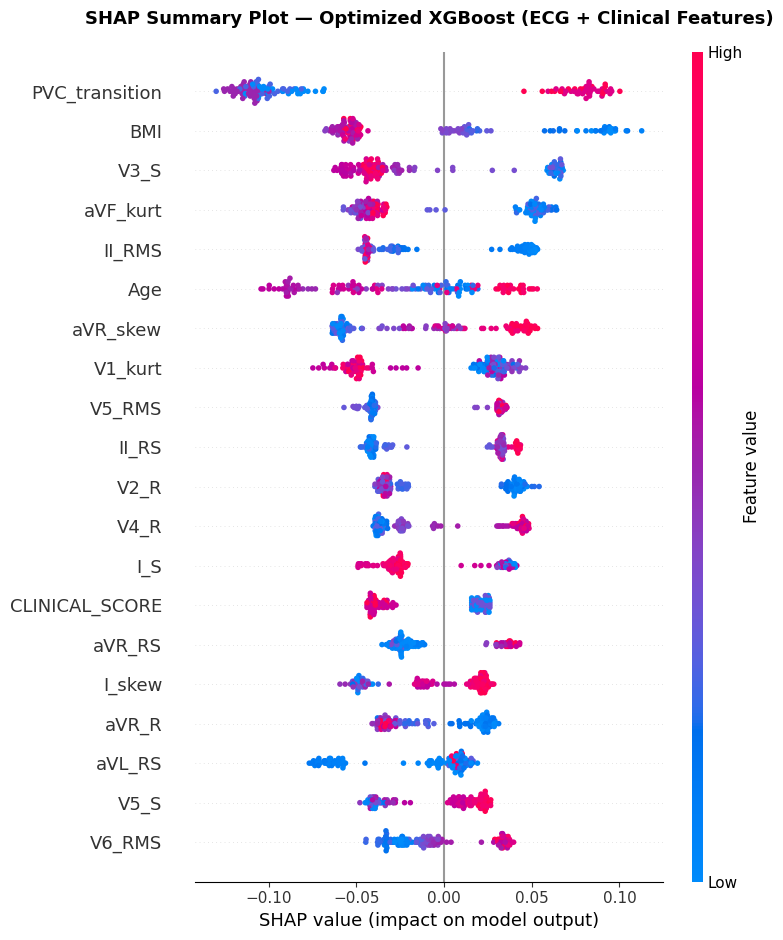

In [ ]:
# Optimizing LogReg via random search
print("\n--- OPTIMIZING LOGISTIC REGRESSION VIA RANDOM SEARCH ---")

lr_base = LogisticRegression(max_iter=3000, random_state=42)

# Define the grid for Logistic Regression
lr_param_dist = {
    "C": np.logspace(-4, 4, 20),                  # Wide range of regularization strengths
    "penalty": ["l1", "l2"],                      # L1 (Lasso) vs L2 (Ridge)
    "solver": ["saga"],                            # 'saga' supports both l1 and l2 for multiclass
    "class_weight": ["balanced", None]            # Helps manage class distributions
}

lr_search = RandomizedSearchCV(
    estimator=lr_base, 
    param_distributions=lr_param_dist, 
    n_iter=20,                                    # 20 combinations is usually enough for LR
    scoring="f1_macro", 
    cv=5, 
    verbose=0, 
    random_state=42, 
    n_jobs=-1
)

lr_search.fit(X_train_t, y_train_t)
print("Best LR Params:", lr_search.best_params_)

# Evaluate Best Logistic Regression
best_lr = lr_search.best_estimator_
best_lr.fit(X_train_t, y_train_t)
y_pred_lr = best_lr.predict(X_test_t)

f1_val_lr = f1_score(y_test_t, y_pred_lr, average='macro', zero_division=0)
print(f"Optimized Logistic Regression Test Macro F1: {f1_val_lr:.4f}")

# Confusion Matrix for Optimized Logistic Regression
cm_lr = confusion_matrix(y_test_t, y_pred_lr)
fig, ax = plt.subplots(figsize=(8, 6))
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=CLASS_NAMES)
disp_lr.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
ax.set_title(f"Optimized LogReg - Teknon+clinical data\n F1score : {f1_val_lr:.4f}", fontsize=12, weight='bold', pad=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# We also optimize XGBoost because it is the algorithm responding better to this type of improvement strategy
print("\n--- OPTIMIZING XGBOOST VIA RANDOM SEARCH ---")
xgb_opt = xgb.XGBClassifier(objective="multi:softprob", num_class=len(np.unique(y_all_tek)), eval_metric="mlogloss", tree_method="hist", random_state=42)
param_dist = {
    "max_depth": [2,3,4,5,6],
    "learning_rate": np.linspace(0.01,0.15,15),
    "n_estimators": [200,400,600,800,1000],
    "subsample": np.linspace(0.6,1.0,5),
    "colsample_bytree": np.linspace(0.6,1.0,5),
    "min_child_weight": [1,3,5,7],
    "gamma": np.linspace(0,0.5,6),
    "reg_lambda": [1,2,5,10]
}

search = RandomizedSearchCV(estimator=xgb_opt, param_distributions=param_dist, n_iter=40, scoring="f1_macro", cv=5, verbose=0, random_state=42, n_jobs=-1)
search.fit(X_train_t, y_train_t)
print("Best XGB Params:", search.best_params_)

# Evaluation of the best performing XGBoost
best_xgb = search.best_estimator_
best_xgb.fit(X_train_t, y_train_t)
y_pred_xgb = best_xgb.predict(X_test_t)

f1_val_xgb = f1_score(y_test_t, y_pred_xgb, average='macro', zero_division=0)
print(f"Optimized XGBoost Test Macro F1: {f1_val_xgb:.4f}")

# Confusion Matrix for Optimized XGBoost
cm_xgb = confusion_matrix(y_test_t, y_pred_xgb)
fig, ax = plt.subplots(figsize=(8, 6))
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=CLASS_NAMES)
disp_xgb.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
ax.set_title(f"Optimized XGBoost - Teknon+clinical data\n F1score : {f1_val_xgb:.4f}", fontsize=12, weight='bold', pad=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Shap analysis for optimized xg-boost
print("\n--- RUNNING SHAP ANALYSIS FOR OPTIMIZED XGBOOST ---")
explainer_xgb = shap.TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_train_t)
shap_array_xgb = np.array(shap_values_xgb)

if not (shap_array_xgb.ndim == 3 and shap_array_xgb.shape[0] == len(CLASS_NAMES)):
    shap_array_xgb = np.transpose(shap_array_xgb, (2, 0, 1))

feature_names_tek = list(X_df_tek.columns)

plt.figure(figsize=(14, 8))
shap.summary_plot(shap_array_xgb.mean(axis=0), X_train_t, feature_names=feature_names_tek, max_display=20, show=False)
plt.title("SHAP Summary Plot — Optimized XGBoost (ECG + Clinical Features)", fontsize=13, weight="bold", pad=20)
plt.tight_layout()
plt.show()